In [1]:
#monty hall problem
import random
import matplotlib.pyplot as plt
import numpy as np 

In [75]:
def monty_hall(simulations):
    wins_cons=np.zeros(simulations)
    wins_switch=np.zeros(simulations)
    wins_new=np.zeros(simulations)     

    for i in range(simulations):
        car=random.randint(1,3)
        player_choice=random.randint(1,3)
        
        doors=[1,2,3]
        doors.remove(player_choice)
        if car in doors:
            doors.remove(car)
        
        #the host opens one of the doors that doesn't have the car behind
        #and that wasn't chosen by the player
        host_opens=random.choice(doors)
        
        #conservative player
        if player_choice==car:
            wins_cons[i]=1

        #switcher player
        remaining_doors = [1,2,3]
        remaining_doors.remove(player_choice)
        remaining_doors.remove(host_opens)
        switch_choice=remaining_doors[0]
        if switch_choice==car:
            wins_switch[i]=1

        #newcomer   
        if random.random() < 0.5:
            final_choice = player_choice
        else:
            final_choice = switch_choice
            
        if final_choice == car:
            wins_new[i] = 1
        
        rate_cons=np.cumsum(wins_cons)/np.arange(1,simulations+1)
        rate_switch=np.cumsum(wins_switch)/np.arange(1,simulations+1)
        rate_new=np.cumsum(wins_new)/np.arange(1,simulations+1)
    return rate_cons, rate_switch, rate_new

    
simulations=10000
cons, switch, new=monty_hall(simulations) 

Final win rates after 10000 games:
Switcher: 67.58%
Conservative: 32.42%
Newcomer: 50.01%


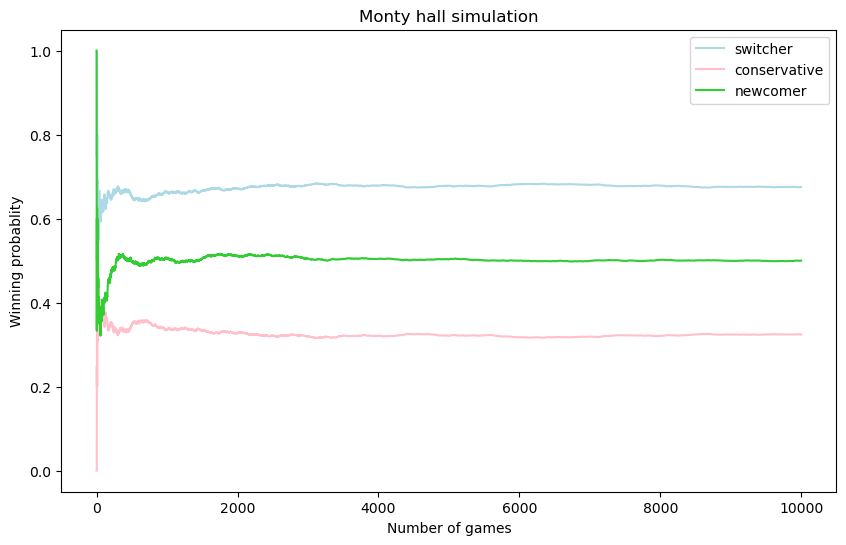

In [77]:
#plot the winning probabilities as a function of the number of games
plt.figure(figsize=(10,6))
plt.plot(switch, label="switcher", color='lightblue')
plt.plot(cons, label='conservative', color='pink')
plt.plot(new, label='newcomer', color='limegreen')

plt.legend()
plt.xlabel('Number of games')
plt.ylabel('Winning probablity')

plt.title('Monty hall simulation')

print(f'Final win rates after {n} games:')
print(f'Switcher: {switch[-1]:.2%}')
print(f'Conservative: {cons[-1]:.2%}')
print(f'Newcomer: {new[-1]:.2%}')
